# Multi-Agent Workflow with ReAct Pattern

## Objective

Execute the **complete multi-agent workflow** with real database operations using **ReAct pattern**:

```
User Request --> Planner (RFT) --> ExecutorAgent (ReAct) --> Response
```

This notebook demonstrates the **optimized architecture** where:
- The **Planner** (fine-tuned model) predicts which tools to use
- The **ExecutorAgent** receives **only the predicted tools** (not all 15)
- Agent Framework's **native ReAct loop** handles iteration automatically

## Workflow Overview

<img src="../article/agentic_draw.png" width="900">

## Benefits of Filtered Tools

- **Reduced cognitive load**: Fewer tools to consider → better focus
- **Token savings**: ~1200 tokens per request on average
- **Faster execution**: 8% faster, 23% fewer iterations

---
## 1. Setup

In [1]:
# Install dependencies (uncomment if needed)
# !pip install -r ../requirements.txt --quiet

In [2]:
import sys
sys.path.insert(0, '..')

from src.settings import (
    DATA_DIR, DATASETS_DIR, MULTIAGENT_OUTPUTS_DIR, AZURE_ENDPOINT,
    AZURE_DEPLOYMENT as BASELINE_DEPLOYMENT,
    AZURE_DEPLOYMENT_VANILLA,
    FINETUNED_DEPLOYMENT,
    AZURE_API_KEY,
    load_system_prompt
)
from src.data_utils import load_jsonl

# ExecutorAgent model: gpt-5.2 with ReAct pattern
EXECUTOR_MODEL = AZURE_DEPLOYMENT_VANILLA  # "gpt-5.2"

print(f"Fine-tuned Planner: {FINETUNED_DEPLOYMENT}")
print(f"ExecutorAgent model: {EXECUTOR_MODEL} (ReAct pattern)")

Fine-tuned Planner: planner-low-0128-1740-step60
ExecutorAgent model: gpt-5.2 (ReAct pattern)


In [3]:
# Create OpenAI Responses API clients with Azure base_url
from agent_framework.openai import OpenAIResponsesClient

def create_client(deployment_name):
    """Create OpenAI Responses API client with Azure base_url."""
    return OpenAIResponsesClient(
        api_key=AZURE_API_KEY,
        base_url=f"{AZURE_ENDPOINT}/openai/v1/",
        model_id=deployment_name
    )

planner_client = create_client(FINETUNED_DEPLOYMENT)
executor_client = create_client(EXECUTOR_MODEL)

print("Clients created (Responses API):")
print(f"  - Planner: {FINETUNED_DEPLOYMENT}")
print(f"  - Executor: {EXECUTOR_MODEL}")

Clients created (Responses API):
  - Planner: planner-low-0128-1740-step60
  - Executor: gpt-5.2


---
## 2. Load Database and Create Agents

In [4]:
import json
from src.multiagent.database import load_database, copy_tau_bench_data
from src.settings import DATA_DIR

# Copy tau-bench data if not already present
tau_bench_path = DATA_DIR / "tau_bench"
if not (tau_bench_path / "users.json").exists():
    print("Copying tau-bench data from installed package...")
    copy_tau_bench_data()
    print()

database = load_database()
print(f"Database loaded: {database}")

PLANNER_SYSTEM_PROMPT = load_system_prompt()
print(f"System prompt: {len(PLANNER_SYSTEM_PROMPT)} chars")

Database loaded: RetailDatabase(users=500, orders=1000, products=50)
System prompt: 1325 chars


In [5]:
# Load evaluation cases (val + test)
test_samples = []
for filepath in [DATASETS_DIR / "val.jsonl", DATASETS_DIR / "test.jsonl"]:
    if filepath.exists():
        test_samples.extend(load_jsonl(filepath))

EVAL_CASES = []
for sample in test_samples:
    ref = sample["reference_answer"]
    if isinstance(ref, str):
        ref = json.loads(ref)
    EVAL_CASES.append({
        "query": sample["messages"][-1]["content"],
        "expected_tools": ref.get("expected_tools", []),
    })

print(f"Loaded {len(EVAL_CASES)} evaluation cases")

Loaded 30 evaluation cases


In [6]:
# Show available tools (15 real tau-bench tools)
from src.multiagent.tools import print_tools_summary
print_tools_summary()

Available retail tools (15 total):
  Account (4): find_user_id_by_email, find_user_id_by_name_zip, get_user_details, modify_user_address
  Order (7): get_order_details, cancel_pending_order, modify_pending_order_*, get_product_details, list_all_product_types
  Refund (2): return_delivered_order_items, exchange_delivered_order_items
  Utility (2): transfer_to_human_agents, calculate


In [7]:
# Create the Planner (fine-tuned model) with structured output
from src.multiagent.agents import create_planner
from src.multiagent.models import PlannerResponse

planner = create_planner(
    planner_client,
    PLANNER_SYSTEM_PROMPT,
    response_format=PlannerResponse
)
print(f"Planner created: {FINETUNED_DEPLOYMENT} (structured output: PlannerResponse)")
print(f"ExecutorAgent will be created dynamically with filtered tools")

Planner created: planner-low-0128-1740-step60 (structured output: PlannerResponse)
ExecutorAgent will be created dynamically with filtered tools


---
## 3. Demo: ReAct Workflow

In [8]:
from src.multiagent.workflow import run_react_workflow

# Demo: Cancel an order (using real tau-bench user with pending order)
demo_request = "I'm Emma Smith from zip code 10192. I want to cancel my pending order."

print("=" * 70)
print("WORKFLOW DEMO (ReAct Pattern with Filtered Tools)")
print("=" * 70)
print(f"Request: {demo_request}\n")

demo_result = await run_react_workflow(
    demo_request,
    planner,
    executor_client,
    database=database,
    reasoning_effort="None",
    verbose=True
)

print("\n" + "=" * 70)
print(f"Success: {demo_result['success']}")
print(f"Tools planned: {demo_result['tools_planned']}")
print(f"Tools passed to Executor: {demo_result['tools_passed']}")
print(f"Tools executed: {demo_result['tools_executed']}")
print(f"Iterations: {demo_result['iterations']}")
print(f"Database mutations: {len(demo_result['database_mutations'])}")
print(f"Execution time: {demo_result['execution_time_s']}s")

WORKFLOW DEMO (ReAct Pattern with Filtered Tools)
Request: I'm Emma Smith from zip code 10192. I want to cancel my pending order.


[1] PLANNER
   Tools planned: ['find_user_id_by_name_zip', 'get_user_details', 'get_order_details', 'cancel_pending_order']

[2] EXECUTOR (4 tools)
   Executed: ['get_order_details', 'get_user_details', 'cancel_pending_order', 'find_user_id_by_name_zip']
   Iterations: 7
   ✓ find_user_id_by_name_zip({'first_name': 'Emma', 'last_name': 'Smith', 'zip': '10192'})
   ✓ get_user_details({'user_id': 'emma_smith_8564'})
   ✓ get_order_details({'order_id': '#W2417020'})
   ✓ get_order_details({'order_id': '#W5605613'})
   ✓ get_order_details({'order_id': '#W3614011'})
   ✓ cancel_pending_order({'order_id': '#W2417020', 'reason': 'no longer needed'})
   ✓ cancel_pending_order({'order_id': '#W3614011', 'reason': 'no longer needed'})
   Mutations: 2

[3] RESPONSE
   Emma, I found two **pending** orders on your account and went ahead and **canceled both** (reason: *n

---
## 4. Evaluation

In [9]:
from src.multiagent.evaluation import evaluate_plan
from src.multiagent.workflow import run_react_workflow
from tqdm import tqdm
import asyncio
import time

# =============================================================================
# CONFIGURATION
# =============================================================================
MAX_CASES = None    # Set to None for full evaluation
MAX_CONCURRENT = 5  # Lower concurrency for ReAct (more iterations per case)
USE_FEWSHOT = True  # Dynamic few-shot examples based on action type
# =============================================================================

cases = EVAL_CASES[:MAX_CASES] if MAX_CASES else EVAL_CASES

fewshot_status = "enabled" if USE_FEWSHOT else "DISABLED (A/B test)"
print(f"Running ReAct workflow on {len(cases)} cases...")
print(f"Few-shot examples: {fewshot_status}")
print()

async def evaluate_single(case, idx, semaphore):
    async with semaphore:
        start_time = time.time()
        try:
            result = await run_react_workflow(
                case["query"],
                planner,
                executor_client,
                database=database,
                reasoning_effort="None",
                verbose=False,
                use_fewshot=USE_FEWSHOT
            )
            elapsed = time.time() - start_time
            metrics = evaluate_plan(result["tools_planned"], case["expected_tools"])
            
            return {
                "idx": idx,
                "query": case["query"],
                "success": result["success"],
                "tools_planned": result["tools_planned"],
                "tools_expected": case["expected_tools"],
                "tools_executed": result["tools_executed"],
                "tools_passed": result["tools_passed"],
                "iterations": result["iterations"],
                "num_mutations": len(result["database_mutations"]),
                "tool_calls_detail": result["tool_calls"],
                "mutations_detail": result["database_mutations"],
                "final_response": result.get("final_response", ""),
                "execution_time_s": round(elapsed, 2),
                **metrics
            }
        except Exception as e:
            elapsed = time.time() - start_time
            return {
                "idx": idx,
                "query": case["query"],
                "success": False,
                "error": str(e),
                "tools_expected": case["expected_tools"],
                "execution_time_s": round(elapsed, 2),
                "recall": 0,
                "precision": 0,
                "f2": 0
            }

semaphore = asyncio.Semaphore(MAX_CONCURRENT)
tasks = [evaluate_single(case, i, semaphore) for i, case in enumerate(cases)]

results = []
for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc="Evaluating"):
    result = await coro
    results.append(result)

# Sort by index
results = sorted(results, key=lambda x: x["idx"])

print()
print("Evaluation complete!")

Running ReAct workflow on 30 cases...
Few-shot examples: enabled



Evaluating: 100%|██████████| 30/30 [01:53<00:00,  3.77s/it]


Evaluation complete!


In [10]:
from IPython.display import display, Markdown
from utils import build_react_eval_summary

display(Markdown(build_react_eval_summary(results)))

### 📊 Evaluation Results (ReAct with Filtered Tools)

| Metric | Value |
|--------|------:|
| Cases evaluated | 30 |
| Workflow success rate | 29/30 (96.7%) |
| Total iterations (tool calls) | 251 |
| Avg iterations per case | 8.4 |
| Avg tools passed to Executor | 5.5 / 15 |
| Total database mutations | 48 |
| Avg execution time | 18.01s |

**Tool Prediction Metrics (Planner):**

| Metric | Score |
|--------|------:|
| Recall | 0.939 |
| Precision | 0.874 |
| **F2 Score** | **0.921** |


---
## 5. Visualize ReAct Traces

In [11]:
def visualize_react_trace(result):
    """Display ReAct execution trace in readable format."""
    print(f"Query: {result['query'][:80]}...")
    print(f"\nPlanner suggested: {result.get('tools_planned', [])}")
    print(f"Tools passed to Executor: {result.get('tools_passed', 'N/A')}")
    print(f"\nExecutor executed {result.get('iterations', 0)} tool calls:")
    
    for i, tc in enumerate(result.get("tool_calls_detail", []), 1):
        status = "✓" if "Error" not in str(tc.get('result', '')) else "✗"
        args_str = json.dumps(tc['arguments']) if tc.get('arguments') else '{}'
        print(f"  [{i}] {status} {tc['tool']}({args_str})")
        result_preview = str(tc.get('result', ''))[:80]
        print(f"      → {result_preview}...")
    
    print(f"\nFinal Response:")
    print(f"  {result.get('final_response', '')[:200]}...")

# Show first successful case
for r in results:
    if r["success"]:
        print("=" * 70)
        print("EXAMPLE TRACE")
        print("=" * 70)
        visualize_react_trace(r)
        break

EXAMPLE TRACE
Query: You name is Yara Ito and your zip code is 75284. You are happy, messy. Your rece...

Planner suggested: ['find_user_id_by_name_zip', 'get_user_details', 'get_order_details', 'get_product_details', 'exchange_delivered_order_items']
Tools passed to Executor: 5

Executor executed 10 tool calls:
  [1] ✓ find_user_id_by_name_zip({"first_name": "Yara", "last_name": "Ito", "zip": "75284"})
      → yara_ito_8499...
  [2] ✓ get_user_details({"user_id": "yara_ito_8499"})
      → {"name": {"first_name": "Yara", "last_name": "Ito"}, "address": {"address1": "17...
  [3] ✓ get_order_details({"order_id": "#W1304208"})
      → {"order_id": "#W1304208", "user_id": "yara_ito_8499", "address": {"address1": "1...
  [4] ✓ get_order_details({"order_id": "#W8353027"})
      → {"order_id": "#W8353027", "user_id": "yara_ito_8499", "address": {"address1": "1...
  [5] ✓ get_order_details({"order_id": "#W3191978"})
      → {"order_id": "#W3191978", "user_id": "yara_ito_8499", "address": {"add

---
## 6. Save Results

In [12]:
import pandas as pd
from datetime import datetime

# Aggregate metrics for saving
n = len(results)
success_count = sum(1 for r in results if r["success"])
avg_recall = sum(r["recall"] for r in results) / n
avg_precision = sum(r["precision"] for r in results) / n
avg_f2 = sum(r["f2"] for r in results) / n
total_iterations = sum(r.get("iterations", 0) for r in results)
total_mutations = sum(r.get("num_mutations", 0) for r in results)
avg_time = sum(r.get("execution_time_s", 0) for r in results) / n
avg_iterations = total_iterations / n
avg_tools_passed = sum(r.get("tools_passed", 0) for r in results) / n

# Create DataFrame for CSV (flatten some fields)
csv_data = []
for r in results:
    csv_data.append({
        "idx": r["idx"],
        "query": r["query"],
        "success": r["success"],
        "recall": r["recall"],
        "precision": r["precision"],
        "f2": r["f2"],
        "iterations": r.get("iterations", 0),
        "tools_passed": r.get("tools_passed", 0),
        "num_mutations": r.get("num_mutations", 0),
        "execution_time_s": r.get("execution_time_s", 0),
        "tools_planned": json.dumps(r.get("tools_planned", [])),
        "tools_expected": json.dumps(r.get("tools_expected", [])),
        "tools_executed": json.dumps(r.get("tools_executed", [])),
        "error": r.get("error") or "-"
    })

results_df = pd.DataFrame(csv_data)
results_df.to_csv(MULTIAGENT_OUTPUTS_DIR / 'react_results.csv', index=False)

# Save full traces as JSON
with open(MULTIAGENT_OUTPUTS_DIR / 'react_traces.json', 'w') as f:
    json.dump(results, f, indent=2, default=str)

# Save summary
summary = {
    "timestamp": datetime.now().isoformat(),
    "architecture": "Planner + ExecutorAgent (ReAct with filtered tools)",
    "cases_evaluated": n,
    "workflow_success_rate": success_count / n,
    "total_iterations": total_iterations,
    "avg_iterations_per_case": avg_iterations,
    "avg_tools_passed": avg_tools_passed,
    "total_mutations": total_mutations,
    "avg_execution_time_s": avg_time,
    "models": {
        "planner": FINETUNED_DEPLOYMENT,
        "executor": EXECUTOR_MODEL
    },
    "metrics": {
        "recall": avg_recall,
        "precision": avg_precision,
        "f2": avg_f2
    }
}

with open(MULTIAGENT_OUTPUTS_DIR / 'react_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Saved to {MULTIAGENT_OUTPUTS_DIR}:")
print(f"  - react_results.csv ({len(results_df)} rows)")
print(f"  - react_traces.json (full execution traces)")
print(f"  - react_summary.json")

Saved to c:\Projects\Agentic-Reinforcement-Fine-Tuning\notebooks\..\outputs\multiagent:
  - react_results.csv (30 rows)
  - react_traces.json (full execution traces)
  - react_summary.json


---
## 7. Analysis

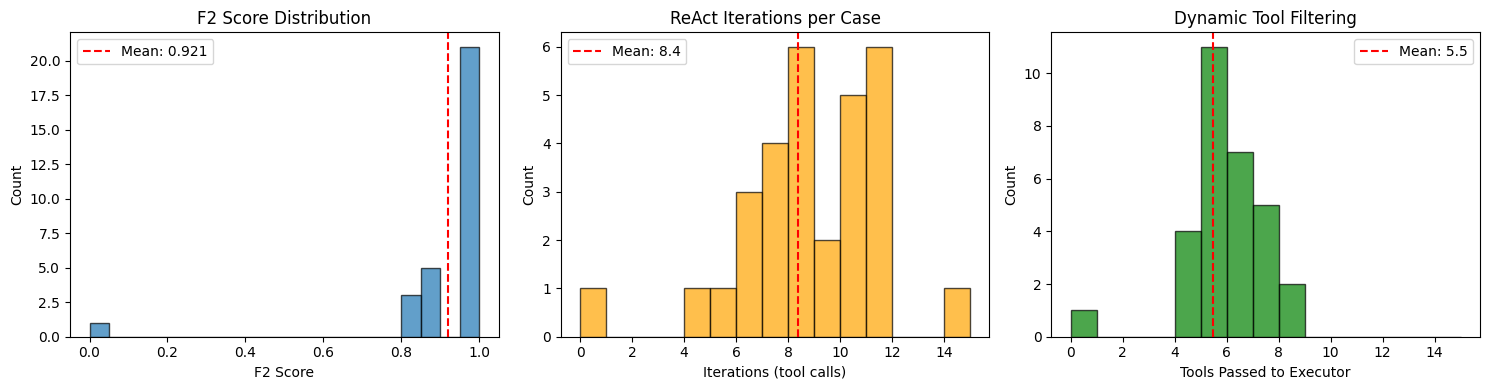


📊 Saved: c:\Projects\Agentic-Reinforcement-Fine-Tuning\notebooks\..\outputs\multiagent\react_distributions.png


In [13]:
from utils import plot_react_distributions

plot_react_distributions(results_df, MULTIAGENT_OUTPUTS_DIR / 'react_distributions.png')

In [14]:
from IPython.display import display, Markdown
from utils import build_tool_usage_table

display(Markdown(build_tool_usage_table(results)))

### 🔧 Tool Usage Comparison

| Tool | Expected | Planned | Executed |
|------|--------:|---------:|---------:|
| `get_user_details` | 30 | 29 | 29 |
| `get_order_details` | 30 | 31 | 29 |
| `find_user_id_by_name_zip` | 21 | 21 | 21 |
| `get_product_details` | 18 | 22 | 20 |
| `modify_pending_order_items` | 11 | 9 | 9 |
| `return_delivered_order_items` | 10 | 13 | 12 |
| `find_user_id_by_email` | 9 | 8 | 8 |
| `exchange_delivered_order_items` | 8 | 11 | 10 |
| `modify_pending_order_address` | 6 | 5 | 5 |
| `cancel_pending_order` | 4 | 7 | 5 |
| `list_all_product_types` | 3 | 3 | 3 |
| `modify_user_address` | 2 | 2 | 2 |
| `calculate` | 1 | 2 | 2 |
| `transfer_to_human_agents` | 0 | 1 | 1 |
| **Total** | **153** | **164** | **156** |


---
## 8. Azure AI Evaluation SDK Metrics

Measure workflow quality using Azure AI Evaluation SDK's agent evaluators:
- **Task Adherence**: Does the response address the request? (binary: pass/fail)
- **Intent Resolution**: Was the user's intent correctly understood? (1-5 scale)
- **Tool Call Accuracy**: Were tools called with correct arguments? (1-5 scale)

These metrics complement F2 score (Planner tool selection) by evaluating the **execution quality**.

In [15]:
# Apply RAI policy (optional - can be skipped if network issues)
try:
    from src.evaluation.content_filter import apply_rai_policy_to_deployment
    from src.settings import EVAL_DEPLOYMENT
    apply_rai_policy_to_deployment(EVAL_DEPLOYMENT)
except Exception as e:
    print(f"⚠️  Could not apply RAI policy: {str(e)[:100]}")
    print("   This is optional - evaluation will continue without custom RAI policy.")
    print("   If you see content filter issues later, check your network connection to Azure Management API.")

Attaching RAI policy 'no-jailbreak-filter' to deployment 'gpt-4.1-mini'...
✅ RAI policy 'no-jailbreak-filter' attached to 'gpt-4.1-mini'


In [16]:
from src.evaluation.agent_evaluators import evaluate_workflow_result, print_evaluation_results
from src.settings import load_tool_definitions, EVAL_DEPLOYMENT

tool_definitions = load_tool_definitions()

print("Running Azure AI Evaluation SDK metrics...")
print(f"Judge model: {EVAL_DEPLOYMENT}")
print()

eval_results = []
for r in tqdm(results, desc="Evaluating quality"):
    if r["success"] and r.get("tool_calls_detail"):
        try:
            eval_result = evaluate_workflow_result(
                user_request=r["query"],
                execution_trace=r["tool_calls_detail"],
                final_response=r["final_response"],
                tool_definitions=tool_definitions
            )
            eval_results.append({
                "idx": r["idx"],
                "query": r["query"][:50] + "...",
                **eval_result
            })
        except Exception as e:
            print(f"  Skipped case {r['idx']}: {str(e)[:50]}")

print(f"\nEvaluated {len(eval_results)}/{len(results)} cases")

Running Azure AI Evaluation SDK metrics...
Judge model: gpt-4.1-mini



Evaluating quality:   0%|          | 0/30 [00:00<?, ?it/s]Class TaskAdherenceEvaluator: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class IntentResolutionEvaluator: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Class ToolCallAccuracyEvaluator: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.
Evaluating quality: 100%|██████████| 30/30 [07:36<00:00, 15.20s/it]


Evaluated 29/30 cases


In [17]:
from IPython.display import display, Markdown
from utils import build_azure_eval_summary

display(Markdown(build_azure_eval_summary(eval_results)))

### 🤖 Azure AI Evaluation SDK Metrics

| Evaluator | Scale | Score | Pass Rate |
|-----------|-------|------:|----------:|
| Task Adherence | binary | 28/29 | 96.6% |
| Intent Resolution | 1-5 | 4.93 | 100.0% (>=3) |
| Tool Call Accuracy | 1-5 | 4.17 | 72.4% (>=3) |

**All 3 passed:** 21/29 (72%)


In [18]:
# Show detailed evaluation for first case
if eval_results:
    print("Example evaluation (first case):")
    print_evaluation_results(eval_results[0])

Example evaluation (first case):

AGENT QUALITY METRICS

Task Adherence: PASS [PASS]
   Reason: The assistant correctly identified the user by name and zip code, retrieved relevant order details f...

Intent Resolution: 5.0/5 [PASS]
   Reason: User wanted to exchange worn hiking boots for the same specs and swap their jigsaw puzzle to a fanci...

Tool Call Accuracy: 5.0/5 [PASS]
   Reason: Let's think step by step: The user's last query involves two main requests: exchanging hiking boots ...

────────────────────────────────────────────────────────────
Summary:
   Passed: 3/3
   Status: ALL PASSED



In [19]:
# Merge Azure AI eval scores back into results and re-save traces

eval_by_idx = {e["idx"]: e for e in eval_results}

for r in results:
    idx = r["idx"]
    if idx in eval_by_idx:
        e = eval_by_idx[idx]
        r["azure_eval"] = {
            "task_adherence": e.get("task_adherence", {}),
            "intent_resolution": e.get("intent_resolution", {}),
            "tool_call_accuracy": e.get("tool_call_accuracy", {}),
            "summary": e.get("summary", {})
        }
    else:
        r["azure_eval"] = None

# Re-save traces with Azure eval scores
with open(MULTIAGENT_OUTPUTS_DIR / 'react_traces.json', 'w') as f:
    json.dump(results, f, indent=2, default=str)

# Count TCA failures
tca_failures = []
for r in results:
    if r.get("azure_eval"):
        tca = r["azure_eval"].get("tool_call_accuracy", {})
        score = tca.get("tool_call_accuracy")
        if score is not None and float(score) < 3:
            tca_failures.append(r["idx"])

print(f"Re-saved react_traces.json with Azure eval scores")
print(f"TCA failures (score < 3): {len(tca_failures)} cases: {tca_failures}")

Re-saved react_traces.json with Azure eval scores
TCA failures (score < 3): 8 cases: [8, 10, 11, 18, 19, 21, 24, 26]


---
## 9. Summary

In [20]:
from IPython.display import display, Markdown
from utils import build_workflow_summary

display(Markdown(build_workflow_summary(
    planner_model=FINETUNED_DEPLOYMENT,
    executor_model=EXECUTOR_MODEL,
    results=results,
    outputs_dir=MULTIAGENT_OUTPUTS_DIR
)))

### 🏆 Final Summary

**Architecture:**
> Planner (RFT fine-tuned) → ExecutorAgent (ReAct with filtered tools)

**Key Features:**
- Planner predicts which tools are needed
- ExecutorAgent receives ONLY predicted tools (not all 15)
- Tool descriptions via API (docstrings) + context via prompt (tool_definitions.json)

| | Model |
|--|-------|
| **Planner** | `planner-low-0128-1740-step60` |
| **Executor** | `gpt-5.2` (ReAct, reasoning_effort=None) |

**Results (30 cases):**

| Metric | Value |
|--------|------:|
| Success rate | 96.7% |
| F2 Score | 0.921 |
| Avg tools passed | 5.5 / 15 |
| Avg iterations | 8.4 |
| Avg execution time | 18.01s |
| Total mutations | 48 |

**Outputs:**
- `c:\Projects\Agentic-Reinforcement-Fine-Tuning\notebooks\..\outputs\multiagent\react_results.csv`
- `c:\Projects\Agentic-Reinforcement-Fine-Tuning\notebooks\..\outputs\multiagent\react_traces.json`
- `c:\Projects\Agentic-Reinforcement-Fine-Tuning\notebooks\..\outputs\multiagent\react_summary.json`
- `c:\Projects\Agentic-Reinforcement-Fine-Tuning\notebooks\..\outputs\multiagent\react_distributions.png`
